# Rellenar los caracteres anonimizados de UC3M-LP

UC3M-LP tapa dos caracteres de cada placa con un rectángulo de color uniforme, y su texto los marca con `*`
(`074*C*V`). Un OCR entrenado así aprende a escribir `*` y lo inventa en placas reales. Este cuaderno pinta en cada
rectángulo un carácter aleatorio y lo escribe en la etiqueta, de modo que las placas quedan completas
(`074*C*V` → `0748CKV`, por ejemplo).

Pasos:

1. **Localizar los rectángulos.** El JSON solo trae las cajas de los caracteres visibles. Cada rectángulo está en el
   hueco entre sus caracteres vecinos, tiene el tamaño de un carácter y un color casi constante, distinto del fondo de
   la placa (y que cambia de una foto a otra). Se busca en ese hueco la ventana del tamaño de un carácter con menor
   variación de color que no tenga el color del fondo, y se ajustan sus bordes.
2. **Banco de caracteres.** Se recortan todos los caracteres visibles del dataset. Todas las placas actuales usan la
   misma tipografía, así que son glifos reales de esa fuente, con iluminación y desenfoque reales.
3. **Rellenar.** En el formato actual español (4 cifras y 3 letras) siempre hay una cifra y una letra tapadas. Cada
   rectángulo se sustituye por una cifra o letra aleatoria del banco, adaptada a la placa: la altura de sus caracteres,
   sus colores de tinta y fondo, su nitidez y su inclinación, sobre un fondo que continúa el de la placa y con bordes
   suavizados.
4. **Generar el dataset** con el mismo formato que `TrOCR_Placas.ipynb` (recortes con margen extra y un CSV por
   partición) en `data/ocr_vehicles/UC3M-LP_ocr_rellenas`, con las mismas placas de validación.

Solo se usan las placas de una fila con el formato actual (`[0-9]{4}[A-Z]{3}`, categoría `A`), el 94 % del dataset.
Se descartan las de formatos antiguos o especiales (`M710*P*`, `R*366BD*`…), las de dos filas y aquellas en las que un
rectángulo no se localiza con seguridad.

## Configuración

`CROP_CONTEXT`, `CROP_MAX_SIDE`, `VALIDATION_FRACTION` y `SEED` tienen los mismos valores que en `TrOCR_Placas.ipynb`.

* `MAX_BLOCK_STD`: desviación de color máxima de un rectángulo (los auténticos están por debajo de 4).
* `MIN_BLOCK_BG_DIST`: distancia de color mínima entre un rectángulo y el fondo de la placa, para no confundirlo con el
  espacio en blanco entre cifras y letras.
* `GLYPH_HEIGHT` y `GLYPHS_PER_CHAR`: altura a la que se guardan los caracteres del banco y máximo por carácter, para
  limitar la memoria.

In [1]:
import os
import json
import math
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFilter
from IPython.display import display
from tqdm.auto import tqdm

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent
UC3M_DIR = Path(os.environ.get("UC3M_DATA_DIR", project_dir / "data" / "ocr_vehicles" / "UC3M-LP"))
DATA_DIR = Path(os.environ.get("PLATES_OCR_FILLED_DIR", project_dir / "data" / "ocr_vehicles" / "UC3M-LP_ocr_rellenas"))

CROP_CONTEXT = (0.25, 0.45)  # igual que en TrOCR_Placas.ipynb
CROP_MAX_SIDE = 768
VALIDATION_FRACTION = 0.1
SEED = 42
MAX_BLOCK_STD = 8.0
MIN_BLOCK_BG_DIST = 20.0
GLYPH_HEIGHT = 96
GLYPHS_PER_CHAR = 250

FORMATO_ACTUAL = re.compile(r"A.-[0-9*]{4}[A-Z*]{3}")
LUMINANCIA = np.array([0.299, 0.587, 0.114])


def leer_anotacion(split, image_id):
    return json.loads((UC3M_DIR / split / f"{image_id}.json").read_text(encoding="utf-8"))


def leer_imagen(split, image_id):
    with Image.open(UC3M_DIR / split / f"{image_id}.jpg") as imagen:
        return np.asarray(imagen.convert("RGB")).copy()


def caracteres_visibles(placa):
    texto = placa["lp_id"].split("-", 1)[1]
    visibles = [i for i, c in enumerate(texto) if c != "*"]
    cajas = {i: placa["characters"][j]["bbox_coord"] for j, i in enumerate(visibles)}
    return texto, visibles, cajas


def tinta_y_fondo(pixeles):
    # tinta = píxeles más oscuros, fondo = píxeles más claros (por luminancia)
    lum = pixeles @ LUMINANCIA
    return pixeles[lum <= np.percentile(lum, 15)].mean(0), pixeles[lum >= np.percentile(lum, 70)].mean(0)


def pixeles_de_caracteres(arr, cajas):
    return np.concatenate([arr[b[0][1]:b[1][1], b[0][0]:b[1][0]].reshape(-1, 3) for b in cajas.values()]).astype(float)

## 1. Localizar los rectángulos

Para cada grupo de `*` seguidos se toma la zona entre el carácter visible anterior y el siguiente (o el borde de la
placa si está en un extremo). En esa zona se calcula, con imágenes integrales, la desviación de color de todas las
ventanas del 80 % del tamaño medio de un carácter; se descartan las que tienen el color del fondo y se elige la de menor
desviación. Después se amplían sus bordes mientras conserven el color del rectángulo, hasta el tamaño de un carácter.
Si hay dos `*` seguidos (`874**HP`), se buscan dos ventanas que no se solapen y se asignan de izquierda a derecha.

In [2]:
def desviacion_ventanas(region, alto, ancho):
    # desviación típica media (RGB) y color medio de cada ventana alto x ancho
    region = region.astype(np.float64)
    def integral(x):
        s = np.zeros((x.shape[0] + 1, x.shape[1] + 1, x.shape[2]))
        s[1:, 1:] = x.cumsum(0).cumsum(1)
        return s
    def suma_ventanas(s):
        return s[alto:, ancho:] - s[:-alto, ancho:] - s[alto:, :-ancho] + s[:-alto, :-ancho]
    n = alto * ancho
    media = suma_ventanas(integral(region)) / n
    varianza = suma_ventanas(integral(region * region)) / n - media * media
    return np.sqrt(np.clip(varianza, 0, None)).mean(-1), media


def localizar_bloques(arr, placa):
    texto, visibles, cajas = caracteres_visibles(placa)
    cw = int(np.median([b[1][0] - b[0][0] for b in cajas.values()]))
    ch = int(np.median([b[1][1] - b[0][1] for b in cajas.values()]))
    alto, ancho = max(1, int(ch * 0.8)), max(1, int(cw * 0.8))
    _, fondo = tinta_y_fondo(pixeles_de_caracteres(arr, cajas))
    bloques = {}
    k = 0
    while k < len(texto):
        if texto[k] != "*":
            k += 1
            continue
        grupo = [k]
        while grupo[-1] + 1 < len(texto) and texto[grupo[-1] + 1] == "*":
            grupo.append(grupo[-1] + 1)
        anterior = max((i for i in visibles if i < k), default=None)
        siguiente = min((i for i in visibles if i > grupo[-1]), default=None)
        vecinos = [cajas[i] for i in (anterior, siguiente) if i is not None]
        # en los extremos, solo el sitio de los caracteres tapados (más un pequeño margen)
        n = len(grupo)
        x0 = cajas[anterior][1][0] if anterior is not None else cajas[siguiente][0][0] - int((n + 0.4) * cw)
        x1 = cajas[siguiente][0][0] if siguiente is not None else cajas[anterior][1][0] + int((n + 0.4) * cw)
        y0 = min(b[0][1] for b in vecinos) - ch // 2
        y1 = max(b[1][1] for b in vecinos) + ch // 2
        x0, y0 = max(0, x0 - cw // 4), max(0, y0)
        x1, y1 = min(arr.shape[1], x1 + cw // 4), min(arr.shape[0], y1)
        region = arr[y0:y1, x0:x1]
        if region.shape[0] <= alto or region.shape[1] <= ancho:
            return None
        desviacion, media = desviacion_ventanas(region, alto, ancho)
        desviacion[np.linalg.norm(media - fondo, axis=-1) < MIN_BLOCK_BG_DIST] = np.inf
        encontrados = []
        for _ in grupo:
            for bx0, by0, bx1, by1 in encontrados:
                desviacion[max(0, by0 - alto + 1):by1, max(0, bx0 - ancho + 1):bx1] = np.inf
            yy, xx = np.unravel_index(np.argmin(desviacion), desviacion.shape)
            if not desviacion[yy, xx] <= MAX_BLOCK_STD:
                return None
            # ampliar los bordes mientras conserven el color, como mucho hasta el tamaño de un carácter
            igual = np.abs(region.astype(np.float64) - media[yy, xx]).max(-1) < 25
            bx0, by0, bx1, by1 = xx, yy, xx + ancho, yy + alto
            max_w, max_h = int(cw * 1.3), int(ch * 1.4)
            while bx0 > 0 and bx1 - bx0 < max_w and igual[by0:by1, bx0 - 1].mean() > 0.7:
                bx0 -= 1
            while bx1 < region.shape[1] and bx1 - bx0 < max_w and igual[by0:by1, bx1].mean() > 0.7:
                bx1 += 1
            while by0 > 0 and by1 - by0 < max_h and igual[by0 - 1, bx0:bx1].mean() > 0.7:
                by0 -= 1
            while by1 < region.shape[0] and by1 - by0 < max_h and igual[by1, bx0:bx1].mean() > 0.7:
                by1 += 1
            if not (0.5 * cw <= bx1 - bx0 <= 2.0 * cw and 0.5 * ch <= by1 - by0 <= 1.8 * ch):
                return None
            # el rectángulo tapa un carácter: su centro vertical está en la franja de los caracteres visibles
            centro_y = y0 + (by0 + by1) / 2
            if not min(b[0][1] for b in vecinos) <= centro_y <= max(b[1][1] for b in vecinos):
                return None
            encontrados.append((bx0, by0, bx1, by1))
        for posicion, (bx0, by0, bx1, by1) in zip(grupo, sorted(encontrados)):
            bloques[posicion] = (x0 + bx0, y0 + by0, x0 + bx1, y0 + by1)
        k = grupo[-1] + 1
    return bloques

## 2. Banco de caracteres

Se recorta cada carácter visible de las placas con formato actual y se guarda reducido a `GLYPH_HEIGHT` píxeles de
alto, como mucho `GLYPHS_PER_CHAR` por carácter (muestreo aleatorio uniforme). Cada partición usa su propio banco.

In [3]:
def extraer_glifos(arr, placa):
    texto, visibles, cajas = caracteres_visibles(placa)
    glifos = []
    for i in visibles:
        (x0, y0), (x1, y1) = cajas[i]
        g = arr[max(0, y0):y1, max(0, x0):x1]
        if g.shape[0] < 8 or g.shape[1] < 3:
            continue
        escala = min(1.0, GLYPH_HEIGHT / g.shape[0])
        g = Image.fromarray(g).resize((max(1, round(g.shape[1] * escala)), max(1, round(g.shape[0] * escala))),
                                      Image.LANCZOS)
        glifos.append((texto[i], np.asarray(g)))
    return glifos


def construir_banco(split, image_ids, rng):
    vistos, banco = {}, {}
    for image_id in tqdm(image_ids, desc=f"banco {split}"):
        placas = [p for p in leer_anotacion(split, image_id)["lps"] if FORMATO_ACTUAL.fullmatch(p["lp_id"])]
        if not placas:
            continue
        arr = leer_imagen(split, image_id)
        for placa in placas:
            for caracter, glifo in extraer_glifos(arr, placa):
                # muestreo de reservorio: como mucho GLYPHS_PER_CHAR por carácter
                vistos[caracter] = vistos.get(caracter, 0) + 1
                lista = banco.setdefault(caracter, [])
                if len(lista) < GLYPHS_PER_CHAR:
                    lista.append(glifo)
                else:
                    j = rng.randrange(vistos[caracter])
                    if j < GLYPHS_PER_CHAR:
                        lista[j] = glifo
    return [(c, g) for c, lista in banco.items() for g in lista]

## 3. Rellenar

Para cada rectángulo se elige al azar un glifo del banco (una cifra si el `*` está entre las 4 primeras posiciones, una
letra si está entre las 3 últimas) y se adapta a la placa:

* se escala a la altura media de los caracteres de la placa;
* se transforman sus colores para que su tinta y su fondo coincidan con los de la placa;
* se desenfoca hasta igualar la nitidez de los caracteres de la placa;
* se centra en el rectángulo, a la altura que marca la inclinación de la placa.

El parche cubre el rectángulo con un margen del 12 % (la mitad se sustituye por completo, para tapar el borde
suavizado por el JPEG). Su fondo es un degradado entre el color de la placa a la izquierda
y a la derecha, con el mismo ruido, y sus bordes se funden con la imagen.

In [4]:
def nitidez(img):
    # gradiente medio normalizado por el contraste del carácter
    g = img @ LUMINANCIA if img.ndim == 3 else img
    if g.shape[0] < 3 or g.shape[1] < 3:
        return 0.0
    contraste = np.percentile(g, 90) - np.percentile(g, 10)
    gradiente = np.abs(np.diff(g, axis=0)).mean() + np.abs(np.diff(g, axis=1)).mean()
    return gradiente / max(contraste, 1.0)


def igualar_nitidez(glifo, objetivo):
    mejor, mejor_diferencia = glifo, abs(nitidez(glifo) - objetivo)
    base = Image.fromarray(np.clip(glifo, 0, 255).astype(np.uint8))
    for radio in (0.5, 0.8, 1.2, 1.6, 2.2, 3.0):
        candidato = np.asarray(base.filter(ImageFilter.GaussianBlur(radio))).astype(float)
        diferencia = abs(nitidez(candidato) - objetivo)
        if diferencia < mejor_diferencia:
            mejor, mejor_diferencia = candidato, diferencia
    return mejor


def fondo_lateral(arr, x0, y0, x1, y1, por_defecto):
    # color claro de una franja a cada lado del parche, interpolado en horizontal
    ancho = max(2, (x1 - x0) // 8)
    lados = []
    for a, b in ((x0 - ancho, x0), (x1, x1 + ancho)):
        a, b = max(0, a), min(arr.shape[1], b)
        if b - a < 1:
            lados.append(None)
            continue
        franja = arr[y0:y1, a:b].reshape(-1, 3).astype(float)
        lum = franja @ LUMINANCIA
        # mediana sin la tinta (el 30 % más oscuro)
        lados.append(np.median(franja[lum >= np.percentile(lum, 30)], axis=0))
    izquierda = next((c for c in lados if c is not None), por_defecto)
    derecha = lados[1] if lados[1] is not None else izquierda
    t = np.linspace(0, 1, x1 - x0)[None, :, None]
    return np.broadcast_to(izquierda * (1 - t) + derecha * t, (y1 - y0, x1 - x0, 3)).copy()


def rellenar_placa(arr, placa, bloques, banco, rng):
    texto, visibles, cajas = caracteres_visibles(placa)
    texto = list(texto)
    pixeles = pixeles_de_caracteres(arr, cajas)
    tinta, fondo = tinta_y_fondo(pixeles)
    lum = pixeles @ LUMINANCIA
    ruido = pixeles[lum >= np.percentile(lum, 70)].std(0)
    alto_glifo = int(np.median([b[1][1] - b[0][1] for b in cajas.values()]))
    nitidez_placa = np.median([nitidez(arr[b[0][1]:b[1][1], b[0][0]:b[1][0]].astype(float)) for b in cajas.values()])
    # centro vertical de los caracteres en función de x (placas inclinadas)
    cx = np.array([(b[0][0] + b[1][0]) / 2 for b in cajas.values()])
    cy = np.array([(b[0][1] + b[1][1]) / 2 for b in cajas.values()])
    pendiente, corte = np.polyfit(cx, cy, 1) if len(cx) > 1 else (0.0, cy[0])
    ruido_rng = np.random.default_rng(rng.randrange(1 << 30))
    # límites horizontales de cada parche: el punto medio con el rectángulo vecino, para no pisar su carácter
    ordenados = sorted(bloques.values())
    limites = {}
    for i, b in enumerate(ordenados):
        izquierda = (ordenados[i - 1][2] + b[0]) // 2 if i > 0 else 0
        derecha = (b[2] + ordenados[i + 1][0]) // 2 if i + 1 < len(ordenados) else arr.shape[1]
        limites[b] = (izquierda, derecha)
    for k, (x0, y0, x1, y1) in bloques.items():
        caracter, glifo = rng.choice([(c, g) for c, g in banco if c.isdigit() == (k < 4)])
        tinta_g, fondo_g = tinta_y_fondo(glifo.reshape(-1, 3).astype(float))
        escala = (fondo - tinta) / np.where(np.abs(fondo_g - tinta_g) < 1, 1, fondo_g - tinta_g)
        ancho_glifo = max(1, round(glifo.shape[1] * alto_glifo / glifo.shape[0]))
        glifo = np.asarray(Image.fromarray(glifo).resize((ancho_glifo, alto_glifo), Image.LANCZOS)).astype(float)
        glifo = igualar_nitidez(np.clip(tinta + (glifo - tinta_g) * escala, 0, 255), nitidez_placa)
        # parche: rectángulo + margen, fondo de la placa con ruido y el glifo centrado
        m = max(3, round((x1 - x0) * 0.12))
        lim_izq, lim_der = limites[(x0, y0, x1, y1)]
        px0, py0 = max(lim_izq, x0 - m), max(0, y0 - m)
        px1, py1 = min(lim_der, x1 + m), min(arr.shape[0], y1 + m)
        parche = fondo_lateral(arr, px0, py0, px1, py1, fondo)
        parche += ruido_rng.normal(0, 1, parche.shape) * ruido * 0.5
        centro_x = (x0 + x1) / 2
        centro_y = pendiente * centro_x + corte
        if not y0 <= centro_y <= y1:
            # la recta de la inclinación no pasa por el rectángulo (pocos caracteres o mal alineados)
            centro_y = (y0 + y1) / 2
        gx0 = round(centro_x - ancho_glifo / 2) - px0
        gy0 = round(centro_y - alto_glifo / 2) - py0
        dx0, dy0 = max(0, gx0), max(0, gy0)
        dx1, dy1 = min(parche.shape[1], gx0 + ancho_glifo), min(parche.shape[0], gy0 + alto_glifo)
        parche[dy0:dy1, dx0:dx1] = glifo[dy0 - gy0:dy1 - gy0, dx0 - gx0:dx1 - gx0]
        # bordes fundidos con la imagen; el rectángulo se sustituye por completo
        alfa = np.ones(parche.shape[:2])
        for i in range(m):
            v = (i + 1) / (m + 1)
            alfa[i, :] = np.minimum(alfa[i, :], v)
            alfa[-1 - i, :] = np.minimum(alfa[-1 - i, :], v)
            alfa[:, i] = np.minimum(alfa[:, i], v)
            alfa[:, -1 - i] = np.minimum(alfa[:, -1 - i], v)
        h2 = m // 2
        alfa[max(0, y0 - py0 - h2):y1 - py0 + h2, max(0, x0 - px0 - h2):x1 - px0 + h2] = 1.0
        zona = arr[py0:py1, px0:px1].astype(float)
        arr[py0:py1, px0:px1] = np.clip(zona * (1 - alfa[..., None]) + parche * alfa[..., None], 0, 255).astype(np.uint8)
        texto[k] = caracter
    return "".join(texto)

## Ejemplos

Con un banco pequeño (200 imágenes de entrenamiento), la localización (rojo) y el resultado en algunas placas:

banco train:   0%|          | 0/200 [00:00<?, ?it/s]

01204: *433*SN → 6433DSN


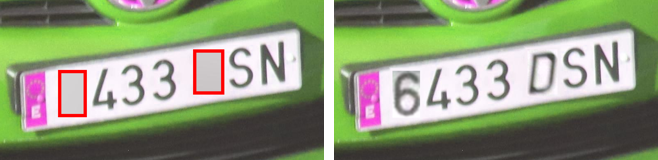

01385: 47*4H*J → 4704HLJ


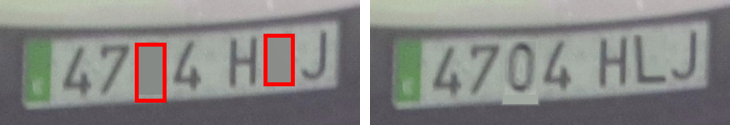

00425 AN-*661*XM descartada
00425: 486**DZ → 4868RDZ


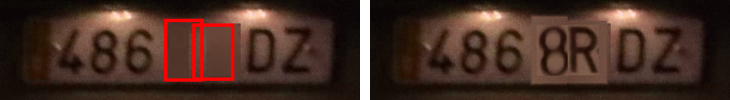

00663: 29*6L*J → 2916LNJ


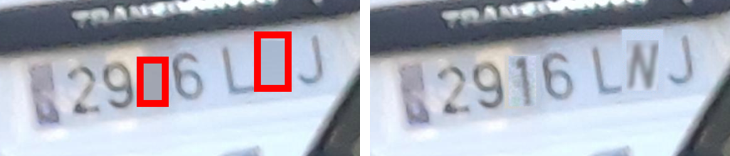

00663: 368**HF → 3684XHF


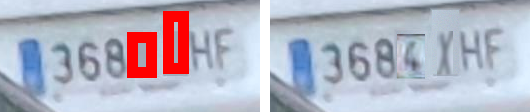

01333: 044**CJ → 0444RCJ


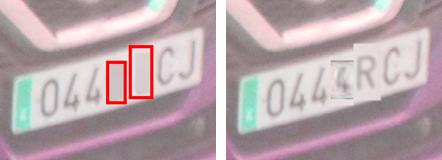

01545: 332*JM* → 3328JMY


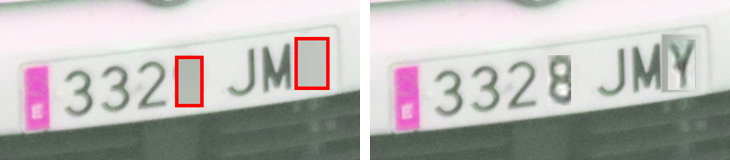

01545: 8*77*BC → 8377VBC


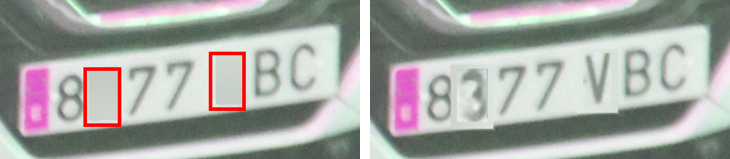

01069: *229*BX → 6229VBX


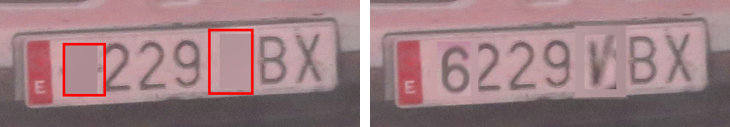

00535: *515GC* → 6515GCC


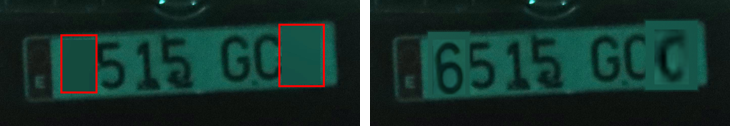

In [5]:
def recorte_placa(placa, margen=(0.08, 0.3)):
    xs = [x for x, _ in placa["poly_coord"]]
    ys = [y for _, y in placa["poly_coord"]]
    w, h = max(xs) - min(xs), max(ys) - min(ys)
    return (min(xs) - w * margen[0], min(ys) - h * margen[1], max(xs) + w * margen[0], max(ys) + h * margen[1])


rng = random.Random(SEED)
ids_train = (UC3M_DIR / "train.txt").read_text(encoding="utf-8").split()
banco_ejemplo = construir_banco("train", rng.sample(ids_train, 200), rng)
for image_id in rng.sample(ids_train, 8):
    arr = leer_imagen("train", image_id)
    for placa in leer_anotacion("train", image_id)["lps"]:
        if not FORMATO_ACTUAL.fullmatch(placa["lp_id"]):
            continue
        bloques = localizar_bloques(arr, placa)
        if bloques is None:
            print(image_id, placa["lp_id"], "descartada")
            continue
        antes = Image.fromarray(arr.copy())
        for caja in bloques.values():
            ImageDraw.Draw(antes).rectangle(caja, outline=(255, 0, 0), width=max(2, antes.width // 800))
        despues = arr.copy()
        texto = rellenar_placa(despues, placa, bloques, banco_ejemplo, rng)
        print(f"{image_id}: {placa['lp_id'].split('-', 1)[1]} → {texto}")
        fila = [antes.crop(recorte_placa(placa)), Image.fromarray(despues).crop(recorte_placa(placa))]
        for im in fila:
            im.thumbnail((360, 160))
        lienzo = Image.new("RGB", (fila[0].width + fila[1].width + 10, max(im.height for im in fila)), "white")
        lienzo.paste(fila[0], (0, 0))
        lienzo.paste(fila[1], (fila[0].width + 10, 0))
        display(lienzo)

## 4. Generar el dataset

Primero se construye el banco de cada partición y después, para cada placa aceptada, se rellena la imagen completa,
se recorta con `CROP_CONTEXT` de margen y se guarda como en `TrOCR_Placas.ipynb`. Las placas de validación son las
mismas que usa ese cuaderno: se eligen agrupando por el texto original de **todas** las placas de `train`, con la misma
semilla. El CSV guarda también el texto original (`text_original`). Si el dataset ya existe no se regenera; para
hacerlo, borra la carpeta.

In [6]:
def ampliar_caja(caja, padding, ancho, alto):
    x0, y0, x1, y1 = caja
    pad_x = (x1 - x0) * padding[0]
    pad_y = (y1 - y0) * padding[1]
    return (
        max(0, int(x0 - pad_x)),
        max(0, int(y0 - pad_y)),
        min(ancho, math.ceil(x1 + pad_x)),
        min(alto, math.ceil(y1 + pad_y)),
    )


def generar_split(split, rng):
    ids = (UC3M_DIR / f"{split}.txt").read_text(encoding="utf-8").split()
    banco = construir_banco(split, ids, rng)
    print(f"banco {split}: {len(banco)} caracteres")
    destino = DATA_DIR / "image" / split
    destino.mkdir(parents=True, exist_ok=True)
    filas, descartes = [], {"formato": 0, "localizacion": 0}
    for image_id in tqdm(ids, desc=split):
        anotacion = leer_anotacion(split, image_id)
        arr = None
        for i, placa in enumerate(anotacion["lps"]):
            if not FORMATO_ACTUAL.fullmatch(placa["lp_id"]):
                descartes["formato"] += 1
                continue
            if arr is None:
                arr = leer_imagen(split, image_id)
            bloques = localizar_bloques(arr, placa)
            if bloques is None:
                descartes["localizacion"] += 1
                continue
            rellena = arr.copy()
            texto = rellenar_placa(rellena, placa, bloques, banco, rng)
            xs = [x for x, _ in placa["poly_coord"]]
            ys = [y for _, y in placa["poly_coord"]]
            caja = (min(xs), min(ys), max(xs), max(ys))
            contexto = ampliar_caja(caja, CROP_CONTEXT, anotacion["imageWidth"], anotacion["imageHeight"])
            escala = min(1.0, CROP_MAX_SIDE / max(contexto[2] - contexto[0], contexto[3] - contexto[1]))
            nombre = f"{split}/{image_id}_{i}.jpg"
            recorte = Image.fromarray(rellena).crop(contexto)
            if escala < 1:
                recorte = recorte.resize((round(recorte.width * escala), round(recorte.height * escala)), Image.LANCZOS)
            recorte.save(DATA_DIR / "image" / nombre, quality=95)
            categoria, texto_original = placa["lp_id"].split("-", 1)
            filas.append({
                "file_name": nombre, "text": texto, "categoria": categoria,
                "x0": (caja[0] - contexto[0]) * escala, "y0": (caja[1] - contexto[1]) * escala,
                "x1": (caja[2] - contexto[0]) * escala, "y1": (caja[3] - contexto[1]) * escala,
                "text_original": texto_original,
            })
    print(split, "descartadas:", descartes)
    return pd.DataFrame(filas)


if all((DATA_DIR / f"{split}.csv").is_file() for split in ("train", "validation", "test")):
    print("Dataset ya generado en", DATA_DIR)
else:
    rng = random.Random(SEED)
    train_all = generar_split("train", rng)
    test_all = generar_split("test", rng)
    # Mismas placas de validación que TrOCR_Placas.ipynb: se eligen entre TODAS las placas de train.
    todas = sorted({placa["lp_id"].split("-", 1)[1] for image_id in ids_train
                    for placa in leer_anotacion("train", image_id)["lps"]})
    random.Random(SEED).shuffle(todas)
    placas_validacion = set(todas[:round(len(todas) * VALIDATION_FRACTION)])
    es_validacion = train_all["text_original"].isin(placas_validacion)
    train_all[~es_validacion].to_csv(DATA_DIR / "train.csv", index=False)
    train_all[es_validacion].to_csv(DATA_DIR / "validation.csv", index=False)
    test_all.to_csv(DATA_DIR / "test.csv", index=False)
    print("Dataset generado en", DATA_DIR)

banco train:   0%|          | 0/1580 [00:00<?, ?it/s]

banco train: 6390 caracteres


train:   0%|          | 0/1580 [00:00<?, ?it/s]

train descartadas: {'formato': 111, 'localizacion': 144}


banco test:   0%|          | 0/395 [00:00<?, ?it/s]

banco test: 2295 caracteres


test:   0%|          | 0/395 [00:00<?, ?it/s]

test descartadas: {'formato': 32, 'localizacion': 27}
Dataset generado en /home/mambauser/workspace/data/ocr_vehicles/UC3M-LP_ocr_rellenas


Resumen y algunas placas rellenadas tal como las verá el entrenamiento:

train: 1620 placas; con '*': 0
validation: 181 placas; con '*': 0
test: 432 placas; con '*': 0
64*3*VP → 6433HVP


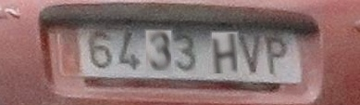

476*GT* → 4766GTV


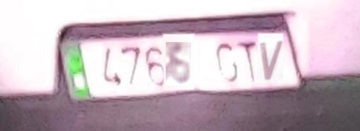

3*84*DN → 3584WDN


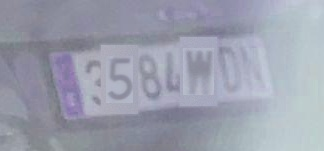

737*HY* → 7372HYC


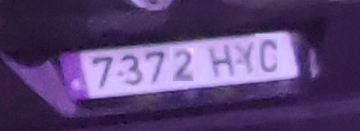

437**DL → 4379RDL


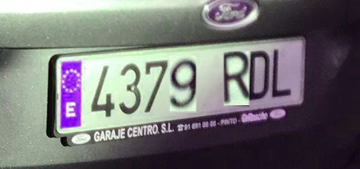

97*2JT* → 9752JTF


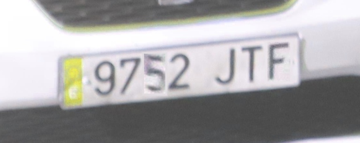

52*3LL* → 5223LLP


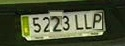

2*52*YN → 2252ZYN


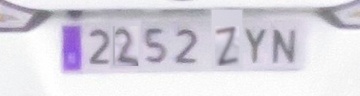

In [7]:
particiones = {split: pd.read_csv(DATA_DIR / f"{split}.csv", dtype={"text": str, "text_original": str})
               for split in ("train", "validation", "test")}
for split, frame in particiones.items():
    print(f"{split}: {len(frame)} placas; con '*': {frame['text'].str.contains('[*]', regex=True).sum()}")

for _, fila in particiones["train"].sample(8, random_state=SEED).iterrows():
    print(f"{fila['text_original']} → {fila['text']}")
    imagen = Image.open(DATA_DIR / "image" / fila["file_name"])
    imagen.thumbnail((360, 200))
    display(imagen)